In [5]:
import importlib
import datetime

import analysis_helpers
from analysis_helpers import open_models

"""
This script loads in responses from classification csv file output by Zooniverse,
and normalizes them into a table with one row per task answered
"""
import logging
from datetime import datetime

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# PARAMETERS
classifications_csv_path = '../4_survey_responses/may-survey-classifications_2025-06-17.csv'
output_dir = '../media/'
prompts_path = '../1_input_prompts/prompts.json'
ml_responses_database_path = '../2_retrieved_responses/records.db'
subjects_path = '../4_survey_responses/review-llm-responses-on-lca-tasks-subjects.csv'
workflow_id = 28845
exclude_prompts = [17]
exclude_models=['ollama_chat/deepseek-r1:8b'] # Deepseek-r1 was run with two inference platforms. We retain the results for the deepseek model with more parameters for a fair comparison

In [6]:
sns.set_theme(style="darkgrid")

In [7]:
current_date = datetime.now().strftime('%Y%m%d')

logging.basicConfig(level=logging.INFO)

# Read classifications
classifications_df = pd.read_csv(classifications_csv_path)
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)


In [8]:
importlib.reload(analysis_helpers)

combined_final = analysis_helpers.load_raw(classifications_csv_path, subjects_path, prompts_json_path=prompts_path, exclude_models=exclude_models, exclude_prompt_ids=exclude_prompts, workflow_id=workflow_id)

In [9]:
combined_final

,original_index,T1,T10,T11,T12,T2,T3,T4,T6,T7,...,response_id,#temperature,#llm_provider,#prompt_run_by,prompt_text,T2_score,T3_score,T4_score,T12_score,count_citations
0,637061162,[],,,No,3 - good,3 - good,Yes,No,"Correct answer, and good explanation",...,1,0.0,mistral,Artur,This question is about materials used to make ...,3,3,1,0,NaN
1,637477134,[],,,No,3 - good,3 - good,Yes,No,,...,16,0.0,mistral,Artur,Give a definition the functional unit of a pro...,3,3,1,0,NaN
2,638491212,[],,,No,3 - good,3 - good,Yes,No,"response is accurate, but a notice that the pr...",...,225,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,3,3,1,0,NaN
3,638512889,"[{'x': 478.4300537109375, 'y': 931.11059570312...","It uses appropiate language, however, as some ...",,Yes,1 - poor,2 - average,No,No,Some claims and numbers are wrong and not supp...,...,231,0.0,bedrock,bhabalaj,You a world class literature review writer. Yo...,1,2,0,1,11.0
4,638515924,"[{'x': 987.8692016601562, 'y': 209.98503112792...",,,No,2 - average,2 - average,Yes,No,"Generally correct, but misses information on t...",...,264,0.0,bedrock,bhabalaj,You are an LCA practitioner executing a study ...,2,2,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,640544574,[],,,No,4 - expert / better than human,3 - good,Yes,No,,...,177,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,4,3,1,0,NaN
164,640545460,[],,"I am not sure, wether the AI model knows to an...",Yes,1 - poor,1 - poor,Yes,Yes,,...,55,0.0,mistral,Artur,What multi-output allocation method should be ...,1,1,1,1,NaN
165,640545715,[],,,No,3 - good,3 - good,Yes,No,,...,250,0.0,bedrock,bhabalaj,Give a definition the functional unit of a pro...,3,3,1,0,NaN
166,640546144,[],,,No,2 - average,1 - poor,Yes,No,,...,59,0.0,gemini,Artur,You are an LCA practitioner executing a study ...,2,1,1,0,NaN


# Create summary for each question

In [10]:

# Group combined_final by prompt_id and # llm_model
grouped_results = (combined_final
.groupby(['prompt_id', '#llm_model'])
.agg({
    'T2_score':'mean',
    'T3_score':'mean',
    'T4_score':'mean',
    'T12_score':'mean',
    'original_index':len})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'incorrect',
    'original_index':'count'
},axis=1))

In [11]:
grouped_results

accuracy  explanation  format  incorrect  count
prompt_id #llm_model                                                        
1         claude-3.7-sonnet  1.000000     3.000000     1.0        1.0      1
          deepseek-r1        2.000000     4.000000     1.0        1.0      1
          gemini-2.0-flash   2.000000     4.000000     1.0        1.0      1
          mistral-large      3.000000     3.000000     1.0        0.0      2
          qwen3              4.000000     4.000000     1.0        0.0      1
...                               ...          ...     ...        ...    ...
24        llama4-maverick    4.000000     1.000000     1.0        1.0      1
          microsoft-phi4     2.500000     2.500000     1.0        0.0      2
          nova-premier-v1    2.666667     2.666667     1.0        0.0      3
          openai-gpt-4.1     3.000000     3.000000     1.0        0.0      1
          qwen3              3.000000     3.000000     1.0        0.0      1

[124 rows x 5 columns]

In [12]:
model_counts = combined_final.groupby('#llm_model').size()

grouped_results_2 = (combined_final
.groupby('#llm_model')
.agg({
    'T2_score':'mean',
    'T3_score':'mean',
    'T4_score':'mean',
    'T12_score':'mean',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'incorrect',
    # 'original_index':'count'
},axis=1))

t12_score_rescaled = (1-grouped_results_2['incorrect']) * 3 + 1 # rescale [0,1] to [1,4]
t4_score_rescaled = grouped_results_2['format']*3 + 1 # rescale [0,1] to [1,4]
grouped_results_2['correctness ^']=t12_score_rescaled
grouped_results_2['format ^']=t4_score_rescaled

del grouped_results_2['format'] # remove format column as it is not needed for heatmap plotting
del grouped_results_2['incorrect'] # remove incorrect column as it is not needed for heatmap plotting
mean_acc_expl = grouped_results_2.agg('mean', axis=1)
grouped_results_2['mean'] = mean_acc_expl
grouped_results_2['count reviews'] = model_counts

# Order by mean
grouped_results_2 = grouped_results_2.sort_values('mean',ascending=False)

grouped_results_2

,accuracy,explanation,correctness ^,format ^,mean,count reviews
#llm_model,,,,,,
llama4-scout,2.750000,3.166667,3.250000,3.500000,3.166667,12
gemini-2.0-flash,2.833333,2.750000,3.250000,3.750000,3.145833,12
openai-gpt-4.1,2.809524,2.761905,3.142857,3.571429,3.071429,21
nova-premier-v1,2.562500,2.750000,3.062500,3.812500,3.046875,16
llama4-maverick,2.375000,2.562500,3.250000,3.625000,2.953125,16
mistral-large,2.312500,2.562500,3.062500,3.437500,2.843750,16
qwen3,2.666667,2.500000,2.666667,3.166667,2.750000,18
microsoft-phi4,2.375000,2.625000,2.687500,3.250000,2.734375,16
claude-3.7-sonnet,2.250000,2.687500,2.500000,3.250000,2.671875,16


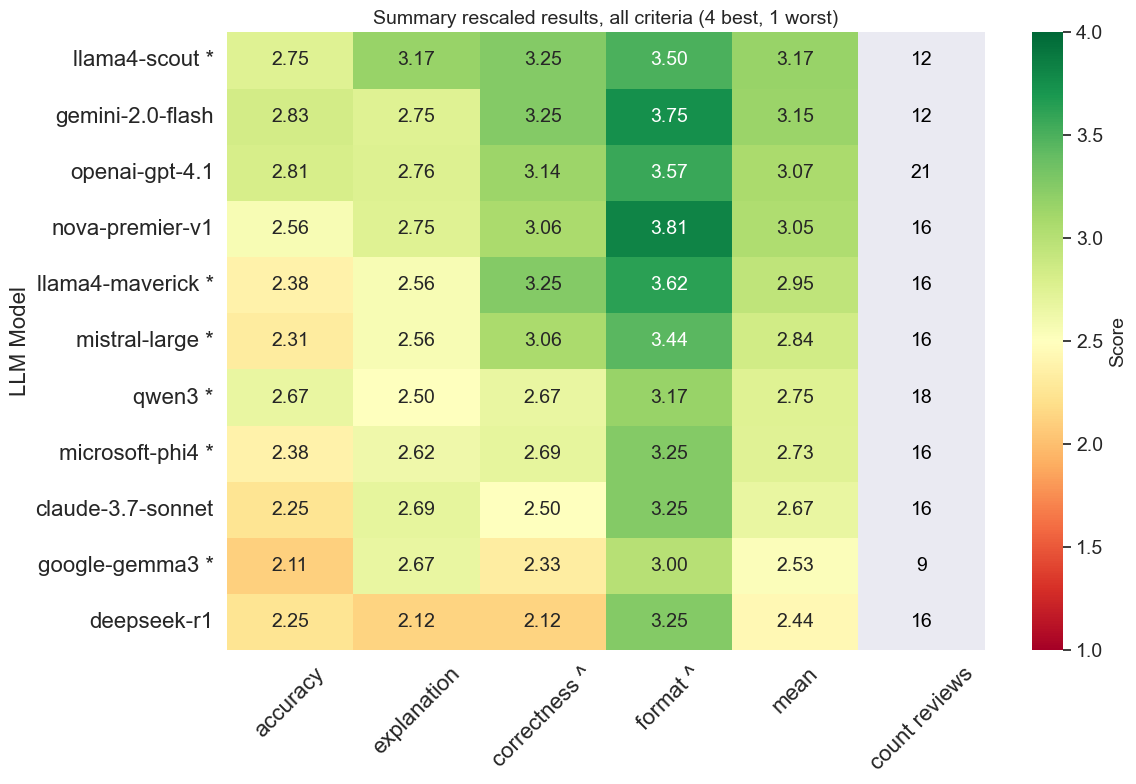

In [18]:
# Create a heatmap of grouped_results
import numpy as np
plt.figure(figsize=(12, 8))

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
grouped_results_reset = grouped_results_2.reset_index()
# Create the heatmap
mask = np.zeros(grouped_results_2.shape)
mask[:,-1] = True
ax = sns.heatmap(grouped_results_2, mask=mask, annot=True, cmap='RdYlGn', vmin=1, vmax=4, fmt='.2f',
            cbar_kws={'label': 'Score'},
             annot_kws={"size": 14})
ax.collections[0].colorbar.ax.tick_params(labelsize=14)
ax.collections[0].colorbar.set_label('Score', fontsize=14)

plt.grid(False)
plt.title('Summary rescaled results, all criteria (4 best, 1 worst)',fontsize=14)
plt.xlabel('')
plt.ylabel('LLM Model', fontsize=16)

# Add missing labels for the masked column
for (j,i), label in np.ndenumerate(grouped_results_2.values):
    if i == grouped_results_2.shape[1]-1:
        ax.text(i+0.5, j+0.5, f'{label:.0f}',
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))

# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_yticklabels()]
plt.xticks(rotation=45,fontsize=16)
plt.yticks(ax.get_yticks(), formatted_labels, rotation=0,ha='right',fontsize=16)

plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_all_criteria.png')
plt.show()


In [14]:
mask = np.zeros(grouped_results_2.shape)
mask[:,-1] = True
mask

array([[0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]])

In [48]:
importlib.reload(analysis_helpers)

<module 'analysis.analysis_helpers' from 'Y:\\projects\\unep-life-cycle-assessment-ml-paper-evaluation\\analysis\\analysis_helpers.py'>

In [39]:
# filter combined_final where prompt_id is in the list `citation_prompts`create a bar chart showing the number of citations (length of the list in combined_final.T1) against the llm_model and prompt_id
citation_results = combined_final[combined_final.prompt_id.isin(analysis_helpers.citation_prompts)]
citation_results.loc[:,'count_citations'] = citation_results.T1.apply(len)


In [40]:
citation_results

,original_index,T1,T10,T11,T12,T2,T3,T4,T6,T7,...,response_id,#temperature,#llm_provider,#prompt_run_by,prompt_text,T2_score,T3_score,T4_score,T12_score,count_citations
3,638512889,"[{'x': 478.4300537109375, 'y': 931.11059570312...","It uses appropiate language, however, as some ...",,Yes,1 - poor,2 - average,No,No,Some claims and numbers are wrong and not supp...,...,231,0.0,bedrock,bhabalaj,You a world class literature review writer. Yo...,1,2,0,1,11.0
5,638520457,[],,,Yes,1 - poor,1 - poor,Yes,No,LCA is not designed to enylze impacts from pop...,...,174,0.0,bedrock,bhabalaj,An energy company plans to assess the conseque...,1,1,1,1,0.0
8,638546061,[],,,No,2 - average,2 - average,Yes,No,The answer is properly drafted. It is a pity i...,...,22,0.0,mistral,Artur,You must conduct an LCA to compare environment...,2,2,1,0,0.0
10,638549744,[],,,No,2 - average,1 - poor,Yes,No,th answer reports some citations which are not...,...,38,0.0,gemini,Artur,What is the carbon footprint of the production...,2,1,1,0,0.0
15,638635870,[],,,No,2 - average,2 - average,Yes,No,The answer is generally of average quality. Re...,...,373,0.0,,,Two independent LCAs of plant-based meat subst...,2,2,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,640289103,"[{'x': 35.33203887939453, 'y': 65.452812194824...",,,No,3 - good,3 - good,Yes,No,,...,27,0.0,openai,Artur,Two independent LCAs of plant-based meat subst...,3,3,1,0,2.0
155,640430922,[],,,Yes,3 - good,3 - good,Yes,No,,...,246,0.0,bedrock,bhabalaj,An energy company plans to assess the conseque...,3,3,1,1,0.0
157,640503298,"[{'x': 91.17430114746094, 'y': 611.28436279296...",,,No,3 - good,3 - good,Yes,No,,...,253,0.0,bedrock,bhabalaj,Two independent LCAs of plant-based meat subst...,3,3,1,0,5.0
160,640541333,"[{'x': 88.1695785522461, 'y': 665.281005859375...",,,No,2 - average,2 - average,Yes,No,,...,157,0.0,bedrock,bhabalaj,Two independent LCAs of plant-based meat subst...,2,2,1,0,5.0


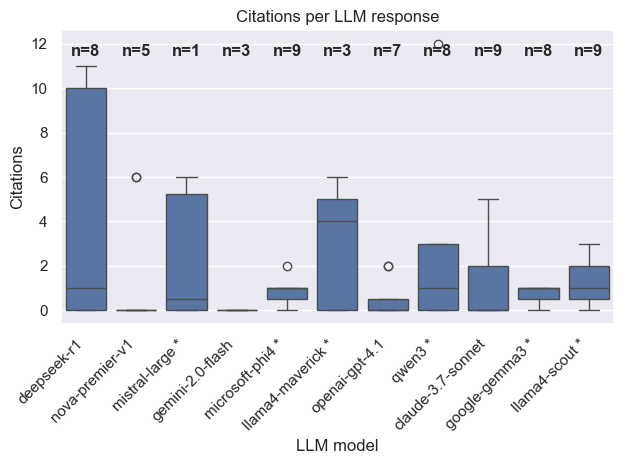

In [41]:
plt.figure()

citation_results.reset_index()
ax = sns.boxplot(citation_results,x='#llm_model',y='count_citations')
# plt.ylim(0, 7)
# Calculate counts per model
model_counts = citation_results.groupby('#llm_model').size()

# Add text labels with counts
for i, (model, count) in enumerate(model_counts.items()):
    ax.text(i, ax.get_ylim()[1] * 0.95, f'n={count}',
            ha='center', va='top', fontweight='bold')

plt.title('Citations per LLM response')
plt.xlabel('LLM model')
plt.ylabel('Citations')
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_boxplot_citations_per_llm.png')
plt.show()

# General summary

In [42]:
summary_binary_correct = combined_final.T12.value_counts()
summary_accuracy = combined_final.T2.value_counts()
summary_explanation = combined_final.T3.value_counts()
summary_format = combined_final.T4.value_counts() # does the response follow the expected format?

In [43]:
summary_binary_correct

T12
No     104
Yes     64
Name: count, dtype: int64

In [44]:
summary_accuracy

T2
3 - good                          77
2 - average                       46
1 - poor                          28
4 - expert / better than human    17
Name: count, dtype: int64

In [17]:
summary_explanation

T3
3 - good                          89
2 - average                       40
1 - poor                          20
4 - expert / better than human    19
Name: count, dtype: int64

In [18]:
summary_format

T4
Yes    136
No      32
Name: count, dtype: int64

In [19]:
grouped_results_2

,accuracy,explanation,mean,mean_acc_expl
#llm_model,,,,
claude-3.7-sonnet,2.250000,2.687500,2.468750,2.468750
deepseek-r1,2.250000,2.125000,2.187500,2.187500
gemini-2.0-flash,2.833333,2.750000,2.791667,2.791667
google-gemma3,2.111111,2.666667,2.388889,2.388889
llama4-maverick,2.375000,2.562500,2.468750,2.468750
llama4-scout,2.750000,3.166667,2.958333,2.958333
microsoft-phi4,2.375000,2.625000,2.500000,2.500000
mistral-large,2.312500,2.562500,2.437500,2.437500
nova-premier-v1,2.562500,2.750000,2.656250,2.656250


In [20]:
combined_final

,original_index,T1,T10,T11,T12,T2,T3,T4,T6,T7,...,response_id,#temperature,#llm_provider,#prompt_run_by,prompt_text,T2_score,T3_score,T4_score,T12_score,count_citations
0,637061162,[],,,No,3 - good,3 - good,Yes,No,"Correct answer, and good explanation",...,1,0.0,mistral,Artur,This question is about materials used to make ...,3,3,1,0,NaN
1,637477134,[],,,No,3 - good,3 - good,Yes,No,,...,16,0.0,mistral,Artur,Give a definition the functional unit of a pro...,3,3,1,0,NaN
2,638491212,[],,,No,3 - good,3 - good,Yes,No,"response is accurate, but a notice that the pr...",...,225,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,3,3,1,0,NaN
3,638512889,"[{'x': 478.4300537109375, 'y': 931.11059570312...","It uses appropiate language, however, as some ...",,Yes,1 - poor,2 - average,No,No,Some claims and numbers are wrong and not supp...,...,231,0.0,bedrock,bhabalaj,You a world class literature review writer. Yo...,1,2,0,1,11.0
4,638515924,"[{'x': 987.8692016601562, 'y': 209.98503112792...",,,No,2 - average,2 - average,Yes,No,"Generally correct, but misses information on t...",...,264,0.0,bedrock,bhabalaj,You are an LCA practitioner executing a study ...,2,2,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,640544574,[],,,No,4 - expert / better than human,3 - good,Yes,No,,...,177,0.0,bedrock,bhabalaj,Most industrial processes produce more than th...,4,3,1,0,NaN
164,640545460,[],,"I am not sure, wether the AI model knows to an...",Yes,1 - poor,1 - poor,Yes,Yes,,...,55,0.0,mistral,Artur,What multi-output allocation method should be ...,1,1,1,1,NaN
165,640545715,[],,,No,3 - good,3 - good,Yes,No,,...,250,0.0,bedrock,bhabalaj,Give a definition the functional unit of a pro...,3,3,1,0,NaN
166,640546144,[],,,No,2 - average,1 - poor,Yes,No,,...,59,0.0,gemini,Artur,You are an LCA practitioner executing a study ...,2,1,1,0,NaN


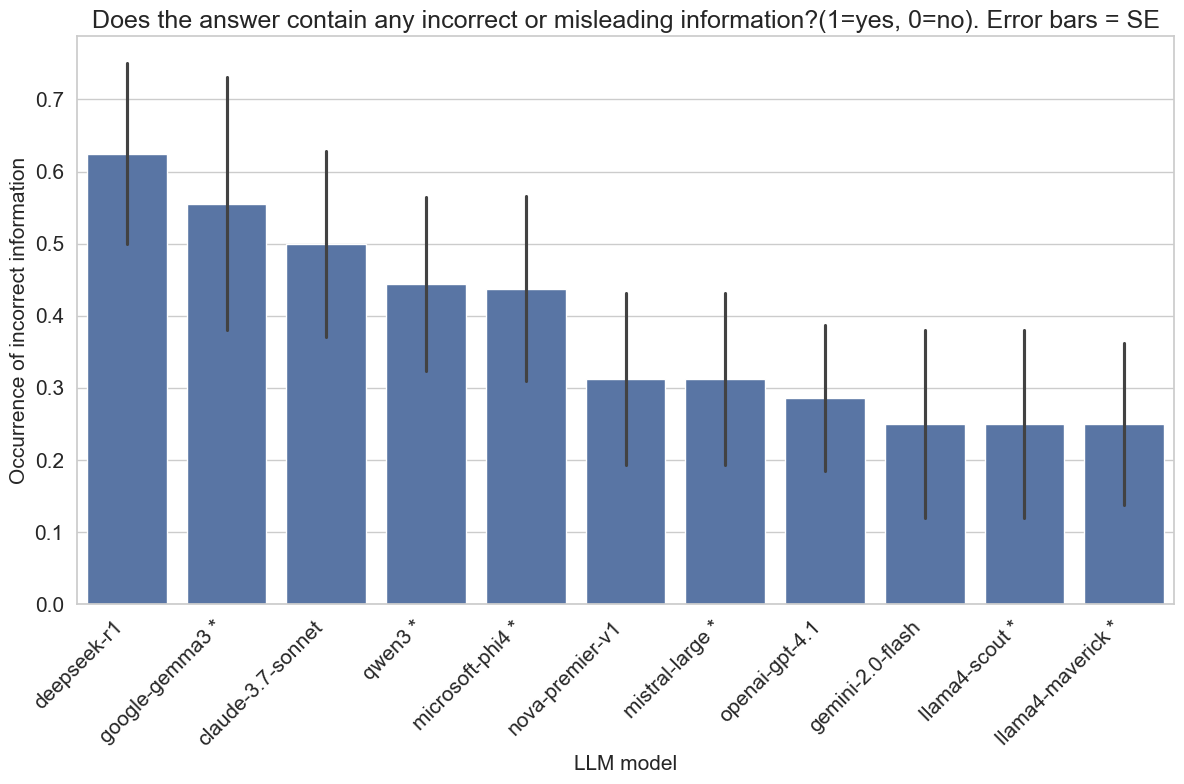

In [213]:
# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model').T12_score.mean().sort_values(ascending=False).index
# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T12_score', errorbar=("se", 1),order=order)

plt.title(
    'Does the answer contain any incorrect or misleading information?(1=yes, 0=no). Error bars = SE',
    fontsize=18)
plt.xlabel('LLM model', fontsize=15)
plt.ylabel('Occurrence of incorrect information', fontsize=15)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_incorrect_per_llm.png')
plt.show()


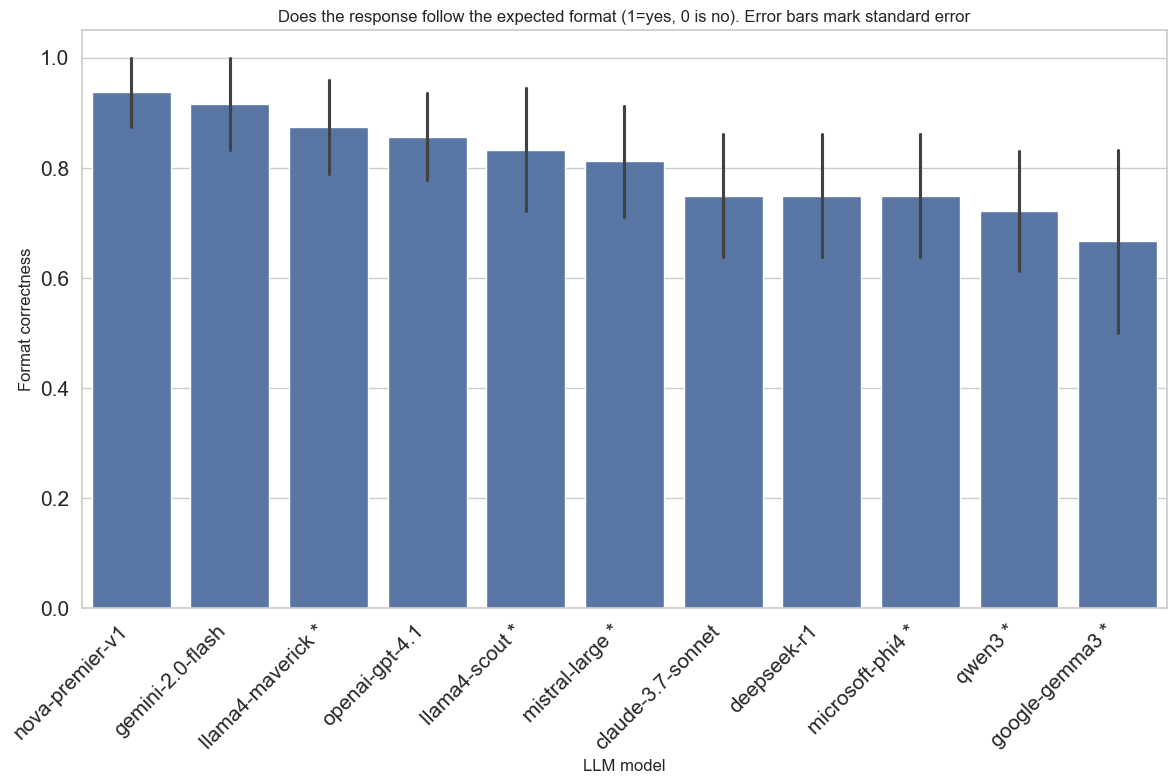

In [215]:

# Create a heatmap of grouped_results
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model').T4_score.mean().sort_values(ascending=False).index

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T4_score',errorbar=("se",1),order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Does the response follow the expected format (1=yes, 0 is no). Error bars mark standard error')
plt.xlabel('LLM model')
plt.ylabel('Format correctness')
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right', fontsize=15)
plt.yticks(rotation=0, fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_format_per_llm.png')
plt.show()


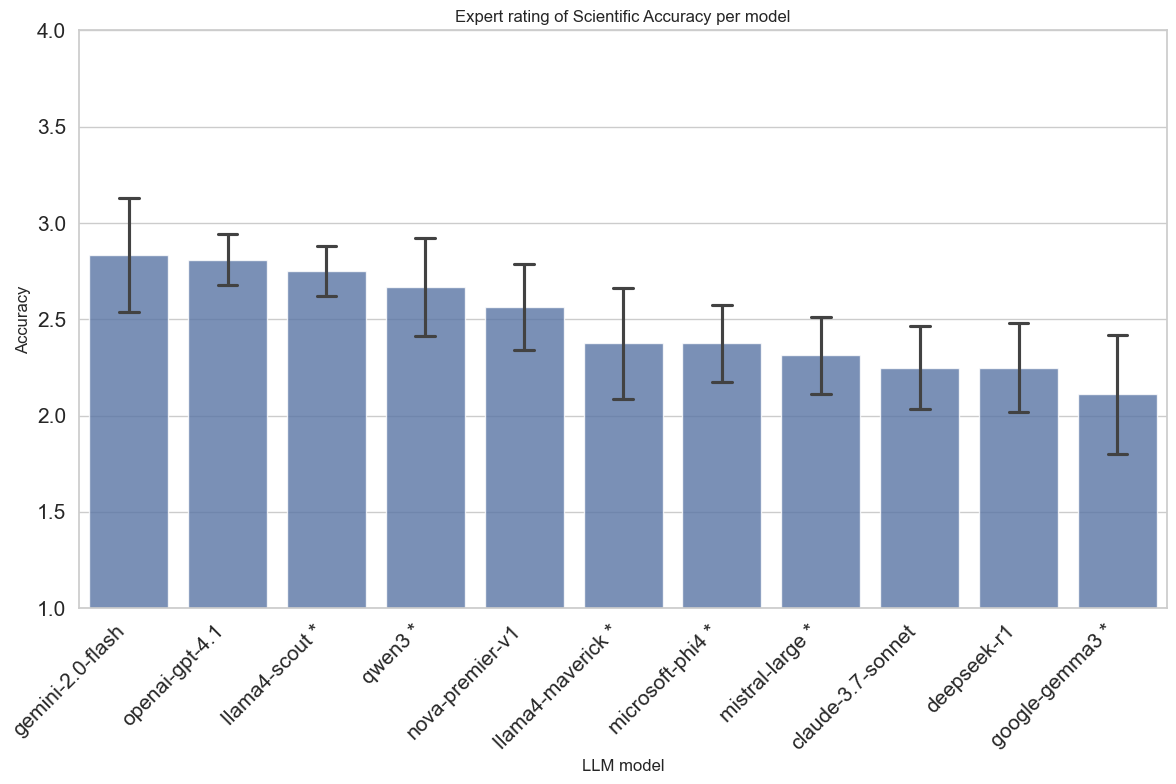

In [227]:
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model')['T2_score'].mean().sort_values(ascending=False).index

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
# grouped_results_reset = grouped_results.reset_index()
# Create the heatmap
ax = sns.barplot(combined_final, x='#llm_model', y='T2_score',errorbar=("se",1), capsize=0.2, alpha=0.8, order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Expert rating of Scientific Accuracy per model')
plt.xlabel('LLM model')
plt.ylabel('Accuracy')
plt.ylim(1,4)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0,fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_accuracy_per_llm.png')
plt.show()


In [158]:
accuracy_df

,mean,sem
#llm_model,,
gemini-2.0-flash,2.833333,0.297294
openai-gpt-4.1,2.809524,0.131277
llama4-scout,2.750000,0.130558
qwen3,2.666667,0.255655
nova-premier-v1,2.562500,0.223024
llama4-maverick,2.375000,0.286865
microsoft-phi4,2.375000,0.201556
mistral-large,2.312500,0.198300
claude-3.7-sonnet,2.250000,0.214087


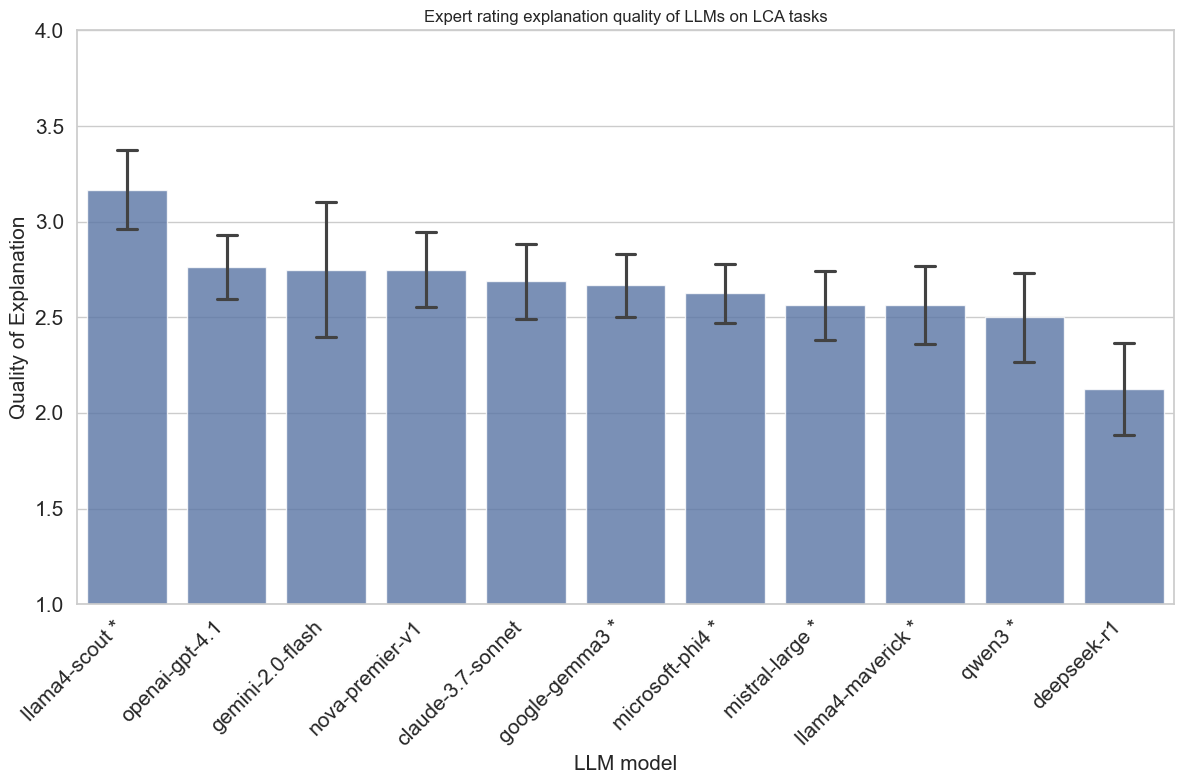

In [228]:
plt.figure(figsize=(12, 8))

order = combined_final.groupby('#llm_model')['T3_score'].mean().sort_values(ascending=False).index
accuracy_df = combined_final.groupby('#llm_model')['T3_score'].agg(['mean','sem']).sort_values('mean',ascending=False)
x_pos = range(accuracy_df.shape[0])
ax = sns.barplot(combined_final, x='#llm_model',y='T3_score', errorbar=('se',1), capsize=0.2, alpha=0.8,order=order)#, cmap='RdYlGn', fmt='.2f')

plt.title('Expert rating explanation quality of LLMs on LCA tasks')
plt.ylim(1,4)
plt.xlabel('LLM model',fontsize=15)
plt.ylabel('Quality of Explanation',fontsize=15)
# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_xticklabels()]
plt.xticks(ticks=ax.get_xticks(),labels=formatted_labels,rotation=45,ha='right',fontsize=15)
plt.yticks(rotation=0,fontsize=15)
plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_explanation_per_llm.png')
plt.show()


In [160]:
# Plot accuracy and explanation side-by-side on the same set of axes

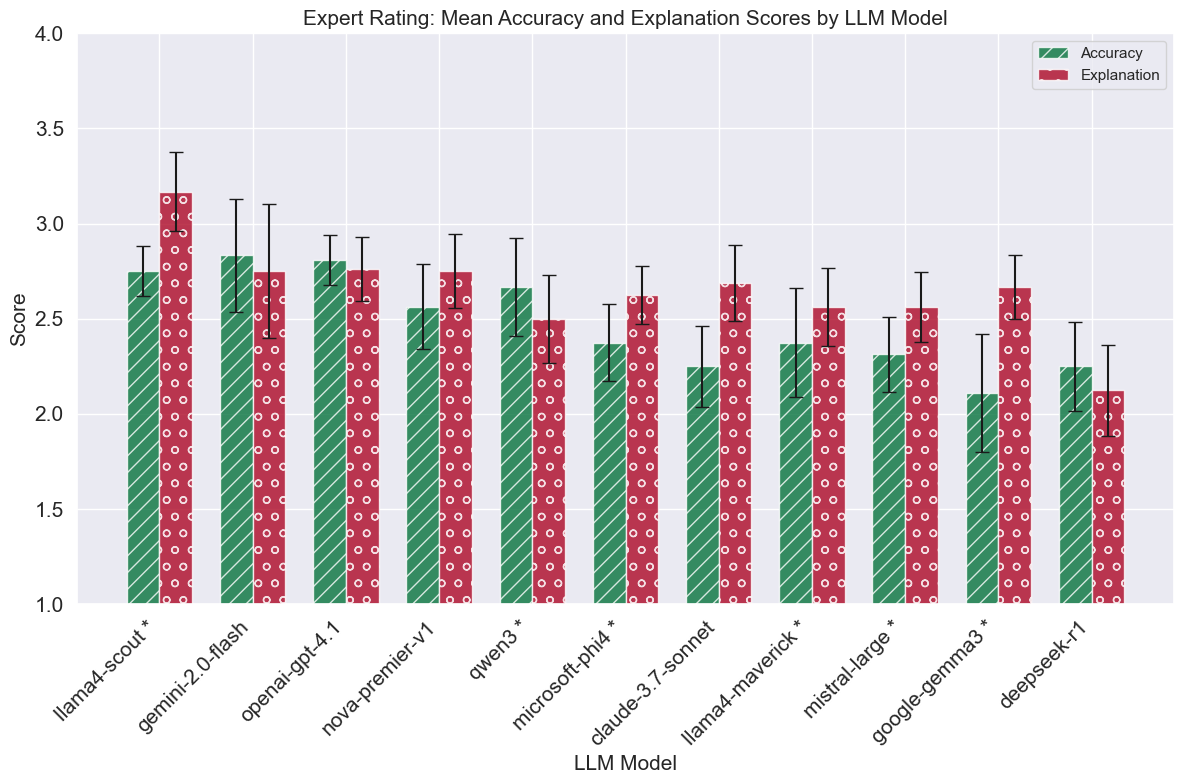

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Calculate counts for each LLM model
counts = combined_final.groupby('#llm_model').size()

# Calculate means and standard errors
grouped_results_3 = (combined_final
    .groupby('#llm_model')
    .agg({
        'T2_score': ['mean', 'sem'],
        'T3_score': ['mean', 'sem']
    })
    .rename({
        'T2_score': 'accuracy',
        'T3_score': 'explanation'
    }, axis=1))

t2_stats = grouped_results_3['accuracy']
t3_stats = grouped_results_3['explanation']

# Calculate mean of accuracy and explanation scores
mean_acc_expl = grouped_results_3[('accuracy', 'mean')] + grouped_results_3[('explanation', 'mean')]
mean_acc_expl = mean_acc_expl / 2  # Average of accuracy and explanation
grouped_results_3.loc[:, 'mean_acc_expl'] = mean_acc_expl

# Order by mean_acc_expl
order = mean_acc_expl.sort_values(ascending=False).index
t2_stats = t2_stats.loc[order]
t3_stats = t3_stats.loc[order]
counts = counts.loc[order]

# Set up bar positions
x = np.arange(len(order))
width = 0.35

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 8))

# Plot accuracy and explanation bars on the primary axis
bars1 = ax1.bar(x - width/2, t2_stats['mean'], width, yerr=t2_stats['sem'], label='Accuracy', color='#06733d', alpha=0.8, capsize=5, hatch='//')
bars2 = ax1.bar(x + width/2, t3_stats['mean'], width, yerr=t3_stats['sem'], label='Explanation', color='#ad0826', alpha=0.8, capsize=5, hatch='o')

# Set labels and title for the primary axis
ax1.set_xlabel('LLM Model', fontsize=15)
ax1.set_ylabel('Score', fontsize=15)
ax1.set_ylim(1, 4)
ax1.set_title('Expert Rating: Mean Accuracy and Explanation Scores by LLM Model', fontsize=15)

# Format x-tick labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label

formatted_labels = [format_label(label) for label in order]
ax1.set_xticks(x)
ax1.set_xticklabels(formatted_labels, rotation=45, ha='right', fontsize=15)
ax1.tick_params(axis='y', labelsize=15)

# Create a secondary y-axis for counts
# ax2 = ax1.twinx()
# ax2.set_ylabel('Counts', fontsize=15, color='#44b')
# ax2.tick_params(axis='y', labelsize=15, labelcolor='#44b')
# ax2.grid(visible=False)
#
# # Plot counts as a bar on the secondary axis
# bars3 = ax2.scatter(x, counts, color='#44b', alpha=0.8, label='Counts')
# # Add counts as text directly over the counts bars
# for i, llm_model in enumerate(order):
#     count = counts[llm_model]
#     ax2.text(x[i], counts[llm_model] + 0.02 * max(counts),  # Position text slightly above the bar
#              f'{count:.0f}',
#              ha='center',
#              va='bottom',
#              fontsize=8,
#              color='black')
# # Adjust the secondary y-axis limits
# ax2.set_ylim(0, max(counts) * 1.1)  # Add 10% padding

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.legend(lines1, labels1, loc='upper right')

# Save and show the plot
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_barchart_accuracy_explanation_counts.png')
plt.tight_layout()
plt.show()


In [240]:
mean_acc_expl
grouped_results_3

accuracy           explanation                mean
                       mean       sem        mean       sem          
#llm_model                                                           
claude-3.7-sonnet  2.250000  0.214087    2.687500  0.198300  2.468750
deepseek-r1        2.250000  0.232737    2.125000  0.239357  2.187500
gemini-2.0-flash   2.833333  0.297294    2.750000  0.350865  2.791667
google-gemma3      2.111111  0.309320    2.666667  0.166667  2.388889
llama4-maverick    2.375000  0.286865    2.562500  0.203485  2.468750
llama4-scout       2.750000  0.130558    3.166667  0.207194  2.958333
microsoft-phi4     2.375000  0.201556    2.625000  0.154785  2.500000
mistral-large      2.312500  0.198300    2.562500  0.181860  2.437500
nova-premier-v1    2.562500  0.223024    2.750000  0.193649  2.656250
openai-gpt-4.1     2.809524  0.131277    2.761905  0.167684  2.785714
qwen3              2.666667  0.255655    2.500000  0.232210  2.583333

In [104]:
type(grouped_results_3['accuracy'])

pandas.core.frame.DataFrame

In [90]:
grouped_results_3.to_csv('accuracy_explanation_scores_with_variance.csv',float_format = "%0.3f")

In [80]:
llm_model
t2_stats.loc[llm_model,'sem']

np.float64(0.3093202423794457)

|# Test Inter-Rater Reliability

In [165]:
classifications_df = pd.read_csv(classifications_csv_path)
classifications_df = analysis_helpers._filter_logged_in_users(classifications_df)

In [166]:
classifications_df

,classification_id,user_name,user_id,user_ip,workflow_id,workflow_name,workflow_version,created_at,gold_standard,expert,metadata,annotations,subject_data,subject_ids
0,637061162,artur-lca,2855607.0,03887b80781b698b0ece,28845,May Survey,1.1,2025-05-06 17:41:44 UTC,NaN,NaN,"{""source"":""api"",""session"":""30991c51b15784fd2ed...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220415"":{""retired"":null,""#date_run"":""2025...",109220415
1,637477134,artur-lca,2855607.0,584746693c9022a4d0fe,28845,May Survey,1.1,2025-05-08 06:33:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""eaf32200486c3dfe0f4...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220647"":{""retired"":null,""#date_run"":""2025...",109220647
7,638491212,NicolasH.,2871905.0,976deb71ab8935a2538b,28845,May Survey,1.1,2025-05-12 13:05:38 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220640"":{""retired"":{""id"":140884037,""workf...",109220640
8,638512889,NicolasH.,2871905.0,8b46272ba49b1b14af3a,28845,May Survey,1.1,2025-05-12 14:05:20 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220444"":{""retired"":null,""#date_run"":""2025...",109220444
9,638515924,NicolasH.,2871905.0,1e71501358ae61444bb2,28845,May Survey,1.1,2025-05-12 14:12:45 UTC,NaN,NaN,"{""source"":""api"",""session"":""019c98980731646c7dc...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220557"":{""retired"":null,""#date_run"":""2025...",109220557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,640544574,NicolasH.,2871905.0,ea5355e09c8ebc41caf2,28845,May Survey,1.1,2025-05-19 15:17:54 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220639"":{""retired"":null,""#date_run"":""2025...",109220639
201,640545460,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:20:42 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220522"":{""retired"":null,""#date_run"":""2025...",109220522
202,640545715,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:21:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220653"":{""retired"":{""id"":140883835,""workf...",109220653
203,640546144,NicolasH.,2871905.0,ce76499b631eab6aee1f,28845,May Survey,1.1,2025-05-19 15:22:22 UTC,NaN,NaN,"{""source"":""api"",""session"":""aeacb21fd1c270e49ba...","[{""task"":""T1"",""task_label"":""Please draw a box ...","{""109220551"":{""retired"":null,""#date_run"":""2025...",109220551


In [167]:
exclude_prompt_ids=[17]

subjects_df = pd.read_csv(subjects_path)
# Extract the prompt_id, llm model and other data from the metadata column
subjects_df = subjects_df.loc[subjects_df.workflow_id == workflow_id]
metadata_df = subjects_df['metadata'].apply(json.loads).apply(pd.Series)
subjects_df = pd.concat([subjects_df, metadata_df], axis=1)

# Apply filters
subjects_df = analysis_helpers._filter_by_models(subjects_df, exclude_models)
subjects_df = analysis_helpers._filter_by_prompt_ids(subjects_df, exclude_prompt_ids)


In [168]:
exploded_dfs = classifications_df['annotations'].apply(analysis_helpers.explode_tasks)
exploded_df = pd.concat(
    exploded_dfs.values,
    keys=exploded_dfs.index,
    names=['original_index', 'task_index']
).reset_index(level='task_index', drop=True)

# Pivot the DataFrame to have one column per task
pivoted_df = exploded_df.pivot(columns='task', values='value').reset_index()
# Re-insert the classification_ids and user_id
pivoted_df['subject_id'] = classifications_df.loc[
    pivoted_df['original_index'], 'subject_ids'
].values
pivoted_df['user_id'] = classifications_df.loc[
    pivoted_df['original_index'], 'user_id'
].values

# Merge and set dtype of prompt_id
combined_df_with_user_id = pivoted_df.merge(subjects_df, on='subject_id', how='inner')
combined_df_with_user_id.prompt_id = combined_df_with_user_id.prompt_id.astype(int)
analysis_helpers._map_scores(combined_df_with_user_id)

In [169]:
combined_df_with_user_id.user_id.value_counts(dropna=False)

user_id
2874233.0    50
2871905.0    20
2872077.0    15
2875376.0    13
2872047.0    12
2874235.0     9
2871772.0     8
2863462.0     8
2855607.0     7
2872141.0     7
2868207.0     6
2874251.0     5
2864613.0     2
2874226.0     2
2874780.0     2
2875535.0     1
2883567.0     1
Name: count, dtype: int64

In [170]:
combined_df_with_user_id.columns

Index(['original_index', 'T1', 'T10', 'T11', 'T12', 'T2', 'T3', 'T4', 'T6',
       'T7', 'T8', 'T9', 'subject_id', 'user_id', 'project_id', 'workflow_id',
       'subject_set_id', 'metadata', 'locations', 'classifications_count',
       'retired_at', 'retirement_reason', 'created_at', 'updated_at',
       '#date_run', 'prompt_id', '#llm_model', 'response_id', '#temperature',
       '#llm_provider', '#prompt_run_by', 'T2_score', 'T3_score', 'T4_score',
       'T12_score'],
      dtype='object')

In [171]:
# Create concatenated column and set as index
df_temp = combined_df_with_user_id[['prompt_id','subject_id','user_id', '#llm_model', 'T3_score']].copy()
# Pivot with user_id as rows and subject_id as columns
pivoted_df = df_temp.pivot_table(index='user_id', columns='subject_id', values='T3_score', aggfunc='mean')
pivoted_df.loc[:,'Counts']= pivoted_df.count(axis=1)
pivoted_df.sort_values('Counts',ascending=False,inplace=True)


## Examine the number of ratings per subject

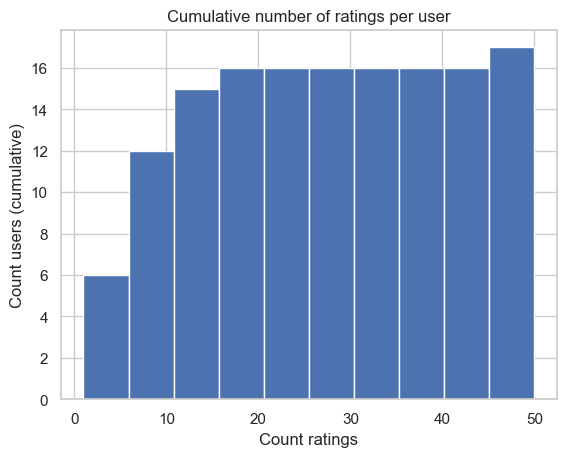

In [172]:
plt.figure()
pivoted_df.Counts.hist(cumulative=True)
plt.title('Cumulative number of ratings per user')
plt.ylabel('Count users (cumulative)')
plt.xlabel('Count ratings')
plt.show()

# Examine  number of ratings per subject

In [173]:
counts_per_subject = pivoted_df.count(axis=0)
counts_per_subject.sort_values(ascending=False)

subject_id
Counts       17
109220615     3
109220692     3
109220603     3
109220686     3
             ..
109220668     1
109220690     1
109220689     1
109220691     1
109220694     1
Length: 125, dtype: int64

In [174]:

subjects_to_include = list(counts_per_subject[counts_per_subject>2].drop('Counts').index.values)
subjects_to_include

[109220603, 109220615, 109220640, 109220675, 109220683, 109220686, 109220692]

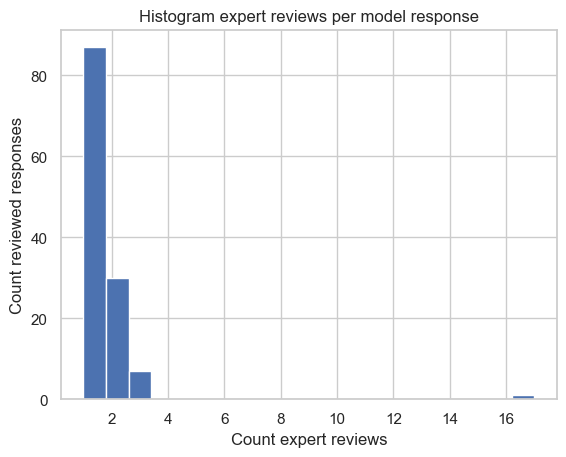

In [175]:
plt.figure()
counts_per_subject.hist(bins=20)
plt.title('Histogram expert reviews per model response')
plt.ylabel('Count reviewed responses')
plt.xlabel('Count expert reviews')
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_accuracy_and_explanation.png')
plt.show()

In [176]:
nullmask = '-'
ratings_q3 = pivoted_df.fillna(nullmask).to_dict('records')

We now have the ratings for each rater in a form we can use with the krippendorf_alpha scripts

In [177]:
ratings_q3

[{109220415: '-',
  109220416: 4.0,
  109220418: 3.0,
  109220420: 4.0,
  109220424: '-',
  109220427: '-',
  109220429: 4.0,
  109220435: '-',
  109220436: '-',
  109220439: '-',
  109220442: 2.0,
  109220443: 3.0,
  109220444: '-',
  109220445: '-',
  109220450: '-',
  109220452: '-',
  109220453: 3.0,
  109220456: '-',
  109220457: '-',
  109220462: '-',
  109220464: '-',
  109220468: '-',
  109220469: '-',
  109220477: 3.0,
  109220478: '-',
  109220480: 1.0,
  109220483: 3.0,
  109220484: 3.0,
  109220500: 3.0,
  109220501: '-',
  109220503: '-',
  109220505: '-',
  109220507: 2.0,
  109220516: '-',
  109220517: '-',
  109220519: 3.0,
  109220521: 3.0,
  109220522: '-',
  109220523: '-',
  109220524: '-',
  109220525: 3.0,
  109220527: '-',
  109220529: 4.0,
  109220532: 3.0,
  109220536: '-',
  109220538: 1.0,
  109220539: '-',
  109220540: '-',
  109220543: '-',
  109220546: '-',
  109220550: 2.0,
  109220551: '-',
  109220552: '-',
  109220555: '-',
  109220557: '-',
  10922055

In [178]:
from krippendorf_alpha import krippendorff_alpha, nominal_metric,interval_metric, ratio_metric
import numpy as np

krippendorf_q3 = krippendorff_alpha(ratings_q3, ratio_metric, missing_items=nullmask)

In [179]:
f'{krippendorf_q3:.3g}'

'0.219'

# Hallucination Rate

In [66]:
import analyze_responses_q1
summary_citation_types_across_models, summary_citations_by_model = analyze_responses_q1.get_hallucination_rates(combined_final, min_citations = 7)

In [67]:
summary_citations_by_model

,T1_correct,T1_not_exist,T1_not_relevant,T1_no_access,count_citations,Hallucination rate
Model name,,,,,,
nova-premier-v1,13,0,0,0,13,0.000000
llama4-scout,8,0,0,0,8,0.000000
openai-gpt-4.1,11,0,0,0,11,0.000000
mistral-large,15,2,0,1,17,0.117647
microsoft-phi4,8,0,2,0,10,0.200000
claude-3.7-sonnet,7,1,1,3,9,0.222222
llama4-maverick,22,5,2,0,29,0.241379
deepseek-r1,22,6,2,0,30,0.266667
qwen3,18,7,1,1,26,0.307692


<Axes: xlabel='Model name', ylabel='T1_no_access'>

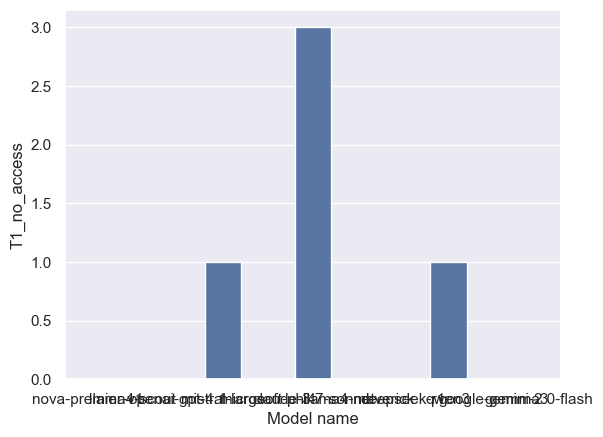

In [70]:
sns.barplot(summary_citations_by_model, x=summary_citations_by_model.index, y='T1_no_access')

In [72]:
summary_citations_by_model['Hallucination rate']

Model name
nova-premier-v1      0.000000
llama4-scout         0.000000
openai-gpt-4.1       0.000000
mistral-large        0.117647
microsoft-phi4       0.200000
claude-3.7-sonnet    0.222222
llama4-maverick      0.241379
deepseek-r1          0.266667
qwen3                0.307692
google-gemma3        0.428571
gemini-2.0-flash          NaN
Name: Hallucination rate, dtype: float64

In [80]:
grouped_results_2

,accuracy,explanation,correctness ^,format ^,mean,count reviews,Hallucination rate
#llm_model,,,,,,,
llama4-scout,2.750000,3.166667,3.250000,3.500000,3.166667,12,0.000000
gemini-2.0-flash,2.833333,2.750000,3.250000,3.750000,3.145833,12,NaN
openai-gpt-4.1,2.809524,2.761905,3.142857,3.571429,3.071429,21,0.000000
nova-premier-v1,2.562500,2.750000,3.062500,3.812500,3.046875,16,0.000000
llama4-maverick,2.375000,2.562500,3.250000,3.625000,2.953125,16,0.241379
mistral-large,2.312500,2.562500,3.062500,3.437500,2.843750,16,0.117647
qwen3,2.666667,2.500000,2.666667,3.166667,2.750000,18,0.307692
microsoft-phi4,2.375000,2.625000,2.687500,3.250000,2.734375,16,0.200000
claude-3.7-sonnet,2.250000,2.687500,2.500000,3.250000,2.671875,16,0.222222


In [129]:
model_counts = combined_final.groupby('#llm_model').size()

grouped_results_4 = (combined_final
.groupby('#llm_model')
.agg({
    'T2_score':'mean',
    'T3_score':'mean',
    'T4_score':'mean',
    'T12_score':'mean',
    # 'original_index':len
})
.rename({
    'T2_score':'accuracy',
    'T3_score':'explanation',
    'T4_score':'format',
    'T12_score':'incorrect',
    # 'original_index':'count'
},axis=1))

t12_score_rescaled = (1-grouped_results_4['incorrect']) * 3 + 1 # rescale [0,1] to [1,4]
t4_score_rescaled = grouped_results_4['format']*3 + 1 # rescale [0,1] to [1,4]
grouped_results_4['correctness ^']=t12_score_rescaled
grouped_results_4['format ^']=t4_score_rescaled

del grouped_results_4['format'] # remove format column as it is not needed for heatmap plotting
del grouped_results_4['incorrect'] # remove incorrect column as it is not needed for heatmap plotting
mean_acc_expl = grouped_results_4.agg('mean', axis=1)
grouped_results_4['mean'] = mean_acc_expl
grouped_results_4['count reviews'] = model_counts

# Order by mean
grouped_results_4 = grouped_results_4.sort_values('mean',ascending=False)

grouped_results_4

,accuracy,explanation,correctness ^,format ^,mean,count reviews
#llm_model,,,,,,
llama4-scout,2.750000,3.166667,3.250000,3.500000,3.166667,12
gemini-2.0-flash,2.833333,2.750000,3.250000,3.750000,3.145833,12
openai-gpt-4.1,2.809524,2.761905,3.142857,3.571429,3.071429,21
nova-premier-v1,2.562500,2.750000,3.062500,3.812500,3.046875,16
llama4-maverick,2.375000,2.562500,3.250000,3.625000,2.953125,16
mistral-large,2.312500,2.562500,3.062500,3.437500,2.843750,16
qwen3,2.666667,2.500000,2.666667,3.166667,2.750000,18
microsoft-phi4,2.375000,2.625000,2.687500,3.250000,2.734375,16
claude-3.7-sonnet,2.250000,2.687500,2.500000,3.250000,2.671875,16


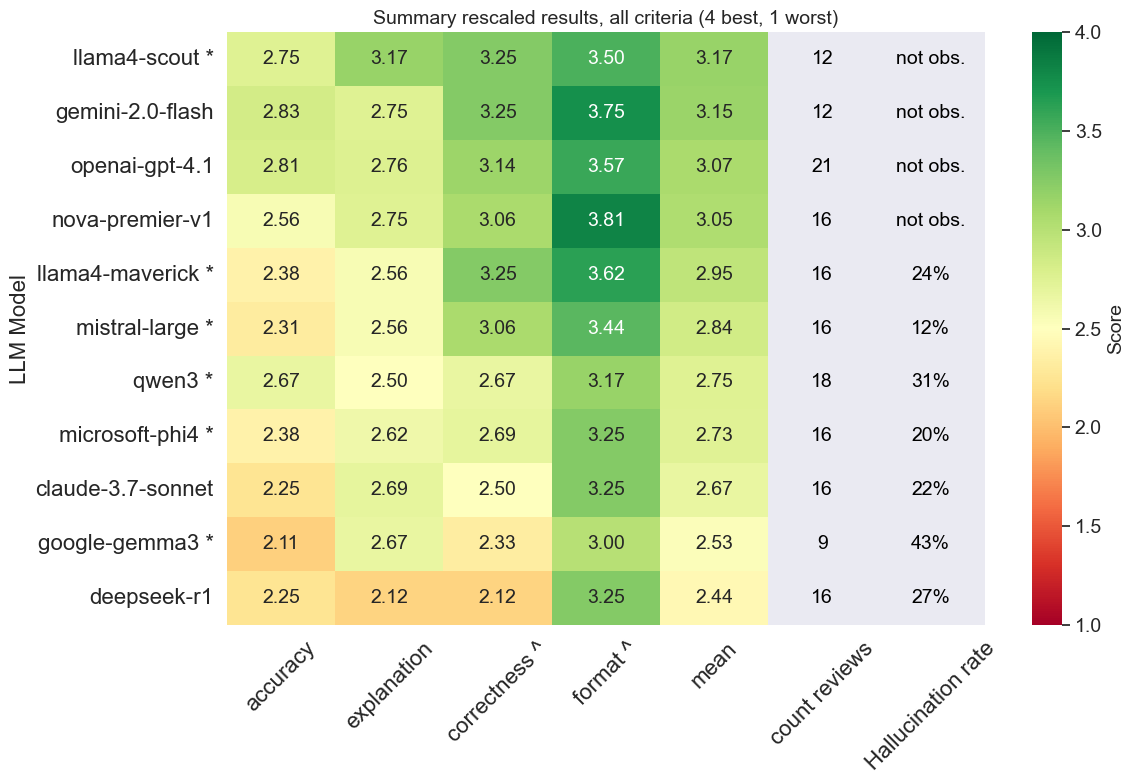

In [130]:
# Create a heatmap of grouped_results
import numpy as np

hallucination_results_formatted = summary_citations_by_model['Hallucination rate'].copy()
hallucination_results_formatted = hallucination_results_formatted.fillna(0)
grouped_results_4.loc[:,'Hallucination rate'] = hallucination_results_formatted
# grouped_results_4.loc[:,'Hallucination rate formatted'] = grouped_results_4.loc[:,'Hallucination rate'].astype(str)
# grouped_results_4.loc[grouped_results_4['Hallucination rate']>0,'Hallucination rate formatted'] = grouped_results_4.loc[grouped_results_4['Hallucination rate']>0,'Hallucination rate']
# grouped_results_4.loc[grouped_results_4['Hallucination rate']==0,'Hallucination rate formatted'] = grouped_results_4.loc[grouped_results_4['Hallucination rate']==0,'count reviews'].apply(lambda x: 1. / x) # Calculate upper bound on hallucination rate. Later on we'll add this an upper bound symbol to the heatmap.
# if 'Hallucination rate' in grouped_results_4.columns:
#     del grouped_results_4['Hallucination rate']
grouped_results_4.rename({'Hallucination rate formatted':'hallucination'}, axis=1, inplace=True)
plt.figure(figsize=(12, 8))

# Reset index to make prompt_id and #llm_model regular columns for easier plotting
grouped_results_reset = grouped_results_4.reset_index()
# Create the heatmap
mask = np.zeros(grouped_results_4.shape)
mask[:,-2] = True
mask[:,-1] = True
ax = sns.heatmap(grouped_results_4, mask=mask, annot=True, cmap='colorblind', vmin=1, vmax=4, fmt='.2f',
            cbar_kws={'label': 'Score'},
             annot_kws={"size": 14})
ax.collections[0].colorbar.ax.tick_params(labelsize=14)
ax.collections[0].colorbar.set_label('Score', fontsize=14)

plt.grid(False)
plt.title('Summary rescaled results, all criteria (4 best, 1 worst)',fontsize=14)
plt.xlabel('')
plt.ylabel('LLM Model', fontsize=16)

# Add missing labels for the masked column
for (j,i), label in np.ndenumerate(grouped_results_4.values):
    if i == grouped_results_4.shape[1]-2:
        ax.text(i+0.5, j+0.5, f'{label:.0f}',
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))
    if i == grouped_results_4.shape[1]-1:
        if label == 0:
            label_formatted = 'not obs.'
        else:
            label_formatted = f'{label:.0%}'
        ax.text(i+0.5, j+0.5, label_formatted,
                fontdict=dict(ha='center',  va='center',
                                         color='#000', fontsize=14))

# Add asterisks to x ticks labels for open models
def format_label(label):
    if label in open_models:
        label = f"{label} *"
    return label
formatted_labels = [format_label(label.get_text()) for label in ax.get_yticklabels()]
plt.xticks(rotation=45,fontsize=16)
plt.yticks(ax.get_yticks(), formatted_labels, rotation=0,ha='right',fontsize=16)

plt.tight_layout()
datestamp = datetime.now().strftime('%Y%m%d-%H%M')
plt.savefig(output_dir / f'{datestamp}_heatmap_all_criteria.png')
plt.show()


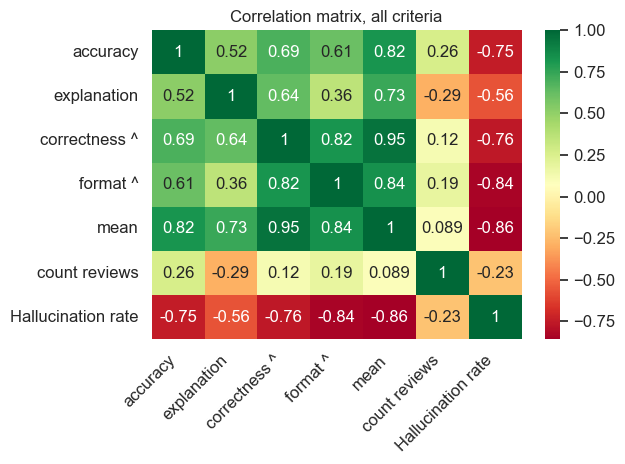

In [143]:
plt.figure()
grouped_results_4['Hallucination ^'] = grouped_results_4['Hallucination rate']
plt.title('Correlation matrix, all criteria',fontsize=12)
ax = sns.heatmap(grouped_results_4.corr(), annot=True, cmap='RdYlGn')
plt.xticks(rotation=45,ha='right',fontsize=12)
plt.yticks(fontsize=12)
ax.collections[0].colorbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig(output_dir / f'{datestamp}_heatmap_all_criteria_corr.png')